# Hotel booking cancellation risk: chronological validation

Public Hotel Booking Demand data, mirrored by TidyTuesday (2020-02-11). The estimated booking date is arrival date minus lead time. Test bookings follow the training period; training outcomes must be resolved before the test cutoff. This is a historical snapshot, not proof that every retained field was unchanged since booking.

The separate lead-time regression is a retrospective booking-profile exercise, not a validated pre-booking forecast.

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, mean_absolute_error, r2_score
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
OUT=ROOT/'outputs'; OUT.mkdir(exist_ok=True)
source=ROOT/'data'/'raw'/'hotel_bookings.csv'
raw=pd.read_csv(source)
# No booking ID is supplied. Identical rows may be different bookings: retain them.
df=raw.copy()
arrival=pd.to_datetime(df['arrival_date_year'].astype(str)+'-'+df['arrival_date_month']+'-'+df['arrival_date_day_of_month'].astype(str),format='%Y-%B-%d')
booking=arrival-pd.to_timedelta(df['lead_time'],unit='D')
resolved=pd.to_datetime(df['reservation_status_date'])
cutoff=booking.sort_values().iloc[int(len(df)*.8)]
scheduled_departure=arrival+pd.to_timedelta(df["stays_in_weekend_nights"]+df["stays_in_week_nights"],unit="D")
# Use fully matured stay cohorts, not only early cancellations with future arrival.
train=(booking<cutoff)&(scheduled_departure<cutoff)&(resolved<cutoff)
test=booking>=cutoff
assert train.any() and test.any() and not (train & test).any()
assert booking[train].max()<booking[test].min()
assert resolved[train].max()<cutoff
print('Rows:',len(df),'Train:',train.sum(),'Test:',test.sum(),'Purged:',(~train&~test).sum(),'Cutoff:',cutoff.date())

Rows: 119390 Train: 79590 Test: 23989 Purged: 15811 Cutoff: 2017-01-12


              model  accuracy  precision  recall     f1  average_precision  roc_auc
     Prior baseline    0.6848     0.0000  0.0000 0.0000             0.3152   0.5000
Logistic Regression    0.6499     0.4676  0.7996 0.5901             0.6438   0.7748
      Random Forest    0.7441     0.6017  0.5569 0.5784             0.6819   0.8089


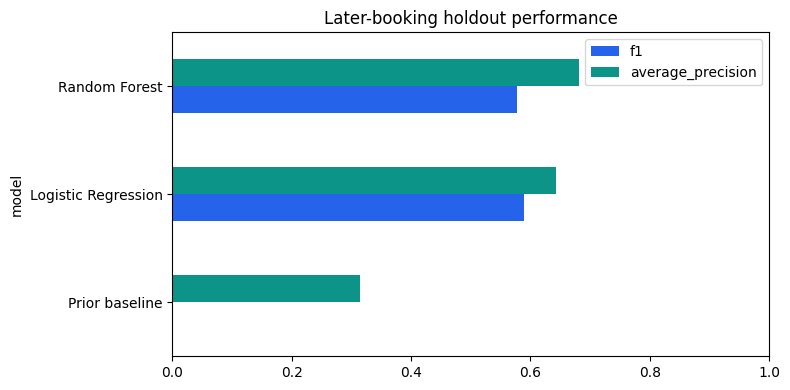

In [2]:
# Explicit feature contract excludes assigned room, booking changes, waiting-list duration,
# final status and mutable special requests/parking counts.
features=['hotel','lead_time','arrival_date_year','arrival_date_month','arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights','stays_in_week_nights','adults','children','babies','meal','country','market_segment','distribution_channel','is_repeated_guest','previous_cancellations','previous_bookings_not_canceled','reserved_room_type','deposit_type','customer_type','adr']
X=df[features]; y=df['is_canceled']
def preprocessing(frame):
    num=frame.select_dtypes(include='number').columns.tolist()
    cat=frame.select_dtypes(exclude='number').columns.tolist()
    return ColumnTransformer([('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num),('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),cat)])
models={'Prior baseline':DummyClassifier(strategy='prior'),'Logistic Regression':LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42),'Random Forest':RandomForestClassifier(n_estimators=200,max_depth=15,class_weight='balanced_subsample',random_state=42,n_jobs=-1)}
rows=[]; fitted={}
for name,model in models.items():
    pipe=Pipeline([('prep',preprocessing(X.loc[train])),('model',model)])
    pipe.fit(X.loc[train],y.loc[train]); fitted[name]=pipe
    pred=pipe.predict(X.loc[test]); prob=pipe.predict_proba(X.loc[test])[:,1]
    rows.append({'model':name,'accuracy':accuracy_score(y.loc[test],pred),'precision':precision_score(y.loc[test],pred,zero_division=0),'recall':recall_score(y.loc[test],pred,zero_division=0),'f1':f1_score(y.loc[test],pred,zero_division=0),'average_precision':average_precision_score(y.loc[test],prob),'roc_auc':roc_auc_score(y.loc[test],prob)})
metrics=pd.DataFrame(rows);metrics.to_csv(OUT/'classification_metrics.csv',index=False)
print(metrics.round(4).to_string(index=False))
metrics.set_index('model')[['f1','average_precision']].plot.barh(figsize=(8,4),color=['#2563eb','#0d9488'])
plt.xlim(0,1);plt.title('Later-booking holdout performance');plt.tight_layout();plt.savefig(OUT/'classification_metrics.png',dpi=160);plt.show()

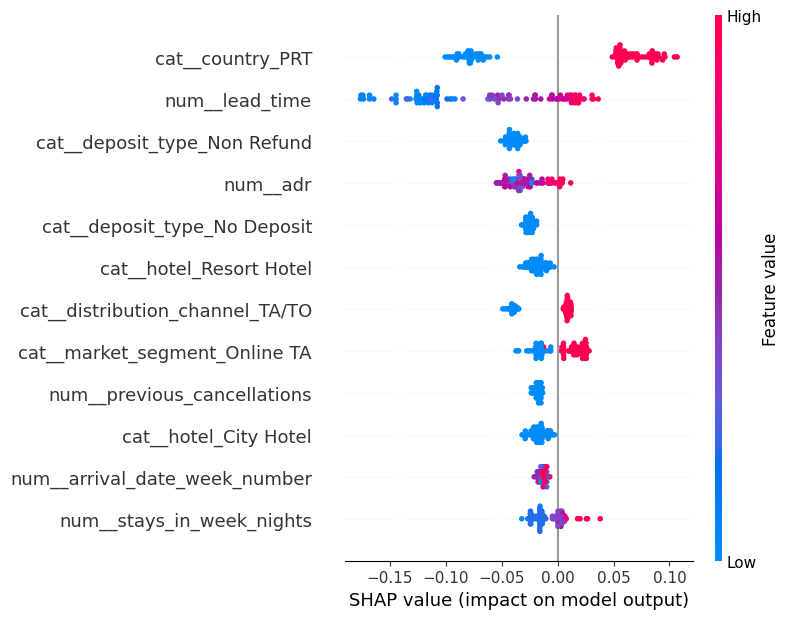

In [3]:
# Explain model behaviour on held-out observations; SHAP is not causal evidence.
import shap
rf=fitted['Random Forest']; xt=rf.named_steps['prep'].transform(X.loc[test].iloc[:100])
sv=shap.TreeExplainer(rf.named_steps['model']).shap_values(xt,check_additivity=False)
sv=sv[1] if isinstance(sv,list) else (sv[:,:,1] if getattr(sv,'ndim',0)==3 else sv)
shap.summary_plot(sv,xt,feature_names=rf.named_steps['prep'].get_feature_names_out(),max_display=12,show=False)
plt.tight_layout();plt.savefig(OUT/'shap_classification.png',dpi=160,bbox_inches='tight');plt.show()

In [4]:
# Retrospective regression uses the same temporal populations; lead_time is removed.
Xr=X.drop(columns='lead_time');yr=df['lead_time'];regrows=[]
regmodels={'Median baseline':DummyRegressor(strategy='median'),'Ridge':Ridge(alpha=1.0),'Gradient Boosting':GradientBoostingRegressor(n_estimators=200,max_depth=5,learning_rate=.1,random_state=42)}
for name,model in regmodels.items():
    pipe=Pipeline([('prep',preprocessing(Xr.loc[train])),('model',model)])
    pipe.fit(Xr.loc[train],yr.loc[train]);pred=pipe.predict(Xr.loc[test])
    regrows.append({'model':name,'mae_days':mean_absolute_error(yr.loc[test],pred),'r2':r2_score(yr.loc[test],pred)})
regmetrics=pd.DataFrame(regrows);regmetrics.to_csv(OUT/'regression_metrics.csv',index=False)
print(regmetrics.round(4).to_string(index=False))
manifest={'source_sha256':hashlib.sha256(source.read_bytes()).hexdigest(),'raw_rows':len(raw),'train_rows':int(train.sum()),'test_rows':int(test.sum()),'purged_rows':int((~train&~test).sum()),'booking_date_cutoff':str(cutoff.date()),'train_cancellation_rate':float(y.loc[train].mean()),'test_cancellation_rate':float(y.loc[test].mean()),'features':features,'split':'inferred booking date; training stays and labels matured before cutoff','threshold':0.5}
(OUT/'validation.json').write_text(json.dumps(manifest,indent=2))

            model  mae_days      r2
  Median baseline   49.1551 -0.0118
            Ridge   80.6205 -1.8323
Gradient Boosting   39.1241  0.1453


## Limits and next decision

The test period is a single later window, not repeated temporal cross-validation. Pricing and customer-profile fields may change between booking and extraction. No live business impact, optimal retention policy or causal effect has been estimated. Select thresholds on a separate validation period with explicit intervention costs before deployment. Legacy figures and office documents describe the earlier random-split experiment; use the outputs linked here for the revised analysis.